In [4]:
# ==================== 数据加载与预处理 ====================
df = pd.read_excel('电商用户数据.xlsx')

# 查看数据信息
df.info()

# 基础清洗
df = df.drop_duplicates().dropna(subset=['城市'])

# 探索性分析
print(f"独特买家数: {df['买家昵称'].nunique()}")
print(f"付款日期范围: {df['付款日期'].min()} ~ {df['付款日期'].max()}")
print("\n订单状态分布:\n", df['订单状态'].value_counts())
print("\n省份分布:\n", df['省份'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 28833 entries, 0 to 28832
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   买家昵称    28833 non-null  str           
 1   付款日期    28833 non-null  datetime64[us]
 2   订单状态    28833 non-null  str           
 3   实付金额    28833 non-null  int64         
 4   邮费      28833 non-null  int64         
 5   省份      28833 non-null  str           
 6   城市      28832 non-null  str           
 7   购买数量    28833 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(4)
memory usage: 1.8 MB
独特买家数: 25948
付款日期范围: 2019-01-01 00:17:59 ~ 2019-06-30 22:46:22.511000

订单状态分布:
 订单状态
交易成功                 27791
付款以后用户退款成功，交易自动关闭     1040
Name: count, dtype: int64

省份分布:
 省份
上海          5808
广东省         3825
北京          2772
江苏省         2408
浙江省         2130
山东省         1052
湖北省         1049
四川省         1004
福建省          898
辽宁省          869
河南省          627
安徽省          616
天津           611
湖

In [ ]:
# ==================== 异常值处理 ====================
def cap_outliers(series, method='iqr', factor=1.5):
    """使用IQR方法截断异常值"""
    Q1, Q3 = np.quantile(series, [0.25, 0.75]) #array([ 72., 178.])
    IQR = Q3 - Q1
    upper = Q3 + factor * IQR
    return series.clip(upper=upper), upper # 将所有大于upper的值替换为upper

df['实付金额'], upper_bound = cap_outliers(df['实付金额'])
print(f"截断上限: {upper_bound}")



NameError: name 'df' is not defined

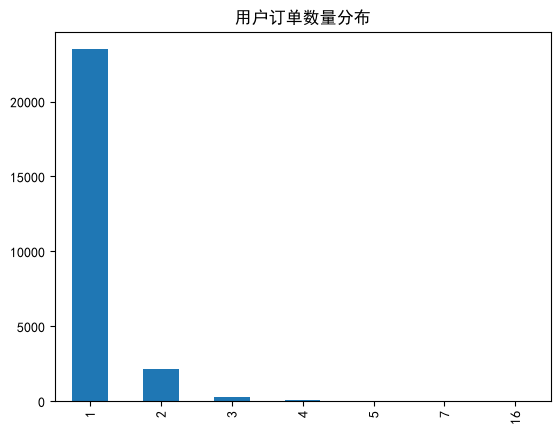

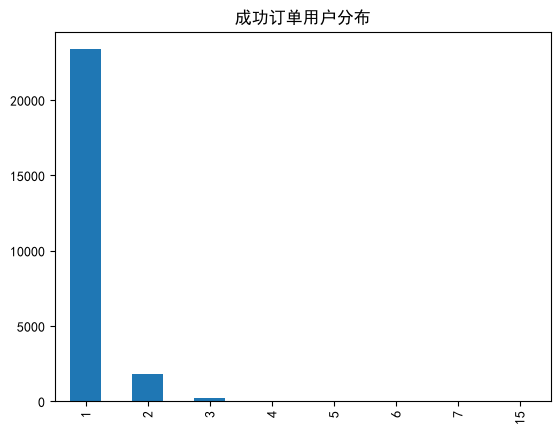

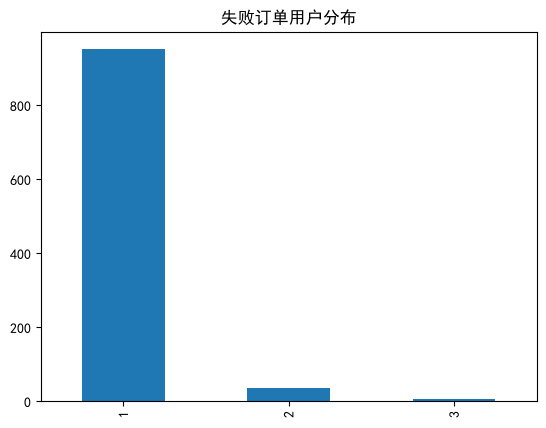

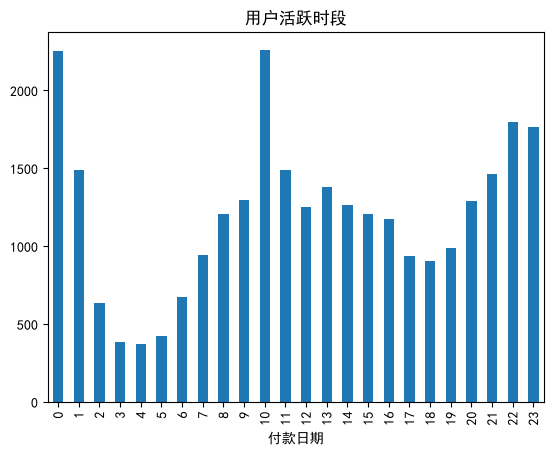

各省份退单率:
 省份
吉林省         0.019084
重庆          0.024145
内蒙古自治区      0.026316
江苏省         0.026578
广西壮族自治区     0.027273
上海          0.029098
云南省         0.029586
贵州省         0.030534
北京          0.031746
天津          0.032733
黑龙江省        0.034325
河南省         0.035088
四川省         0.035857
湖南省         0.037037
陕西省         0.038306
辽宁省         0.039125
河北省         0.040000
福建省         0.040089
广东省         0.041046
山东省         0.041825
海南省         0.042017
山西省         0.042169
浙江省         0.043192
新疆维吾尔自治区    0.045455
湖北省         0.049571
江西省         0.052198
安徽省         0.055195
甘肃省         0.068702
青海省         0.080000
宁夏回族自治区     0.106383
西藏自治区       0.333333
Name: count, dtype: float64


In [9]:
# ==================== EDA可视化 ====================
# 用户订单分布
df.groupby('买家昵称').size().value_counts().plot.bar(title='用户订单数量分布')
plt.show()

SUCCESS = '交易成功'
FAIL = '付款以后用户退款成功，交易自动关闭'

# 交易状态分布
# 成功订单用户分布
df[df['订单状态'] == SUCCESS].groupby('买家昵称').size().value_counts().plot.bar(title='成功订单用户分布')
plt.show()

# 失败订单用户分布
df[df['订单状态'] != SUCCESS].groupby('买家昵称').size().value_counts().plot.bar(title='失败订单用户分布')
plt.show()

# 活跃时段
df['付款日期'].dt.hour.value_counts().sort_index().plot.bar(title='用户活跃时段')
plt.show()

# 各省份退单率
refund_rate = (df[df['订单状态'] != SUCCESS]['省份'].value_counts() / df['省份'].value_counts()).sort_values()
print("各省份退单率:\n", refund_rate)

In [11]:
# ==================== 羊毛党识别 ====================
def identify_fraudsters(df):
    """识别净金额为负的羊毛党用户"""
    temp = df.groupby(['买家昵称', '订单状态'])['实付金额'].sum().reset_index()
    temp['净金额'] = np.where(temp['订单状态'] == SUCCESS, temp['实付金额'], -temp['实付金额'])
    
    fraudsters = temp.groupby('买家昵称')['净金额'].sum()
    return fraudsters[fraudsters < 0].index

fraud_users = identify_fraudsters(df)
print(f"疑似羊毛党用户: {len(fraud_users)}人")


疑似羊毛党用户: 757人


In [ ]:
# ==================== RFM模型 ====================
def build_rfm(df):
    """构建RFM模型"""
    success_orders = df[df['订单状态'] == SUCCESS] #df里订单状态==SUCCESS的订单
    
    rfm = success_orders.groupby('买家昵称').agg({
        '付款日期': 'max',
        '买家昵称': 'size',
        '实付金额': 'sum'
    }).rename(columns={'付款日期': 'last_purchase', '买家昵称': 'f', '实付金额': 'm'})
    
    # 计算R值
    rfm['r'] = (rfm['last_purchase'].max() - rfm['last_purchase']).dt.days
    
    Q2 = np.quantile(df['实付金额'], 0.5)
    Q2 #中位数=115
       
    # RFM二值化（阈值根据业务调整r-最近购买时间，f-购买频次，m-消费金额。120-4个月有购买Q2-Q3, 2-至少买过2次算有粘性, 中位数=115）
    thresholds = {'r': 120, 'f': 2, 'm': 115}
    rfm['R'] = (rfm['r'] <= thresholds['r']).astype(int).astype(str)
    rfm['F'] = (rfm['f'] >= thresholds['f']).astype(int).astype(str)
    rfm['M'] = (rfm['m'] >= thresholds['m']).astype(int).astype(str)
    
    rfm['rfm_label'] = rfm['R'] + rfm['F'] + rfm['M']
    
    # 添加用户类型标签
    rfm['用户类型'] = rfm['rfm_label'].map({
        '111': '核心用户',
        '110': '高频低消费',
        '101': '高价值潜力',
        '100': '新用户',
        '011': '需挽回高价值',
        '010': '需挽回普通',
        '001': '高价值沉睡',
        '000': '低价值沉睡'
    })
    
    return rfm

rfm_result = build_rfm(df)
print("\nRFM分组结果:")
print(rfm_result['rfm_label'].value_counts())
print("\n用户类型分布:")
print(rfm_result['用户类型'].value_counts())


RFM分组结果:
rfm_label
000    6481
101    6338
100    5934
001    4614
111    1242
011     526
110     209
010      75
Name: count, dtype: int64

用户类型分布:
用户类型
低价值沉睡     6481
高价值潜力     6338
新用户       5934
高价值沉睡     4614
核心用户      1242
需挽回高价值     526
高频低消费      209
需挽回普通       75
Name: count, dtype: int64


In [13]:
# ==================== 用户评分模型 ====================
def build_score_model(df, last_time):
    """构建用户综合评分模型"""
    # 数据预处理
    df_processed = df.copy()
    df_processed.loc[df['订单状态'] != SUCCESS, ['购买数量', '实付金额']] = 0
    df_processed['是否退单'] = (df['订单状态'] != SUCCESS).astype(int)
    
    # 聚合特征
    score = df_processed.groupby('买家昵称').agg({
        '付款日期': 'max',
        '买家昵称': 'size',
        '实付金额': 'sum',
        '是否退单': 'sum',
        '购买数量': 'sum'
    }).rename(columns={'买家昵称': '购买频次', '实付金额': 'm'})
    
    score['r'] = (last_time - score['付款日期']).dt.days
    
    # 各维度评分（二值化）
    features = {
        '退单分': ('是否退单', lambda x: 0 if x > 0 else 1),
        '数量分': ('购买数量', lambda x: 1 if x >= 2 else 0),
        'R分': ('r', lambda x: 0 if x >= 120 else 1),
        'F分': ('购买频次', lambda x: 1 if x >= 2 else 0),
        'M分': ('m', lambda x: 1 if x >= 124 else 0)
    }
    
    for col, (source, func) in features.items():
        score[col] = score[source].apply(func)
    
    score['总分'] = score[list(features.keys())].sum(axis=1)
    
    # 添加用户等级
    score['用户等级'] = score['总分'].map({
        5: '顶级用户',
        4: '优质用户',
        3: '良好用户',
        2: '普通用户',
        1: '需提升用户',
        0: '待激活用户'
    })
    
    return score

score_result = build_score_model(df, rfm_result['last_purchase'].max())
print("\n评分分布:")
print(score_result['总分'].value_counts().sort_index())
print("\n用户等级分布:")
print(score_result['用户等级'].value_counts())


评分分布:
总分
0     234
1    4740
2    9041
3    8944
4    1798
5    1191
Name: count, dtype: int64

用户等级分布:
用户等级
普通用户     9041
良好用户     8944
需提升用户    4740
优质用户     1798
顶级用户     1191
待激活用户     234
Name: count, dtype: int64


In [17]:
# ==================== 退单分析 ====================
# 总体退单率
total_refund_rate = (df['订单状态'] == FAIL).sum() / len(df)
print(f"总体退单率: {total_refund_rate:.2%}") 
#f""可以在字符串中直接嵌入变量
#:.2%表示保留两位小数的百分比格式

# 退单用户数
refund_users = df[df['订单状态'] == FAIL]['买家昵称'].nunique()
print(f"退单用户数: {refund_users}人")

# 退单金额统计
refund_amount = df[df['订单状态'] == FAIL]['实付金额'].sum()
print(f"退单总金额: {refund_amount:.2f}元")



总体退单率: 3.61%
退单用户数: 993人
退单总金额: 129339.00元


In [ ]:
# ==================== 保存结果（可选） ====================
# rfm_result.to_excel('RFM分析结果.xlsx')
# score_result.to_excel('用户评分结果.xlsx')
# print("\n结果已保存！")

In [7]:
# ==================== 精确计算羊毛党退款占比 ====================

# 1. 识别羊毛党
fraud_users = identify_fraudsters(df)  # 返回净金额<0的用户列表

# 2. 计算羊毛党退款总额
fraud_refund = df[
    (df['买家昵称'].isin(fraud_users)) & 
    (df['订单状态'] == '付款以后用户退款成功，交易自动关闭')
]['实付金额'].sum()

# 3. 计算全部退款总额
total_refund = df[
    df['订单状态'] == '付款以后用户退款成功，交易自动关闭'
]['实付金额'].sum()

# 4. 计算占比
fraud_refund_ratio = fraud_refund / total_refund * 100

print(f"羊毛党退款金额: {fraud_refund:.2f} 元")
print(f"全部退款金额: {total_refund:.2f} 元")
print(f"羊毛党退款占比: {fraud_refund_ratio:.1f}%")

羊毛党退款金额: 103430.00 元
全部退款金额: 129339.00 元
羊毛党退款占比: 80.0%
